<a href="https://colab.research.google.com/github/sashamontgomery/Neur-265/blob/main/FinalProjectNEUR265.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dementia Data Analysis

In [6]:
#importing relevant modules
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [7]:
#importing alzheimer's data
Alz_ID = pd.read_csv('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/alzheimers_IDs_final_project.csv')
Alz_pathology = pd.read_csv('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/alzheimers_pathology_final_project.csv')

#merging Alz_ID and Alz_pathology data sets
Alz_data = pd.merge(Alz_ID,Alz_pathology, on = 'Donor ID', how = 'inner')



In [8]:
#making AT8 and 6e10 gray matter variables
AT8_graymatter = Alz_data['total AT8 positive area_Grey matter']
Sixe10_graymatter = Alz_data['total 6e10 positive area_Grey matter']

#looking at cognitive status variable
Alz_data['Cognitive Status']

,Cognitive Status
0,No dementia
1,No dementia
2,No dementia
3,Dementia
4,No dementia
...,...
79,Dementia
80,Dementia
81,Dementia
82,Dementia


Text(0.5, 1.0, '6e10 Protein Distribution: Gray Matter')

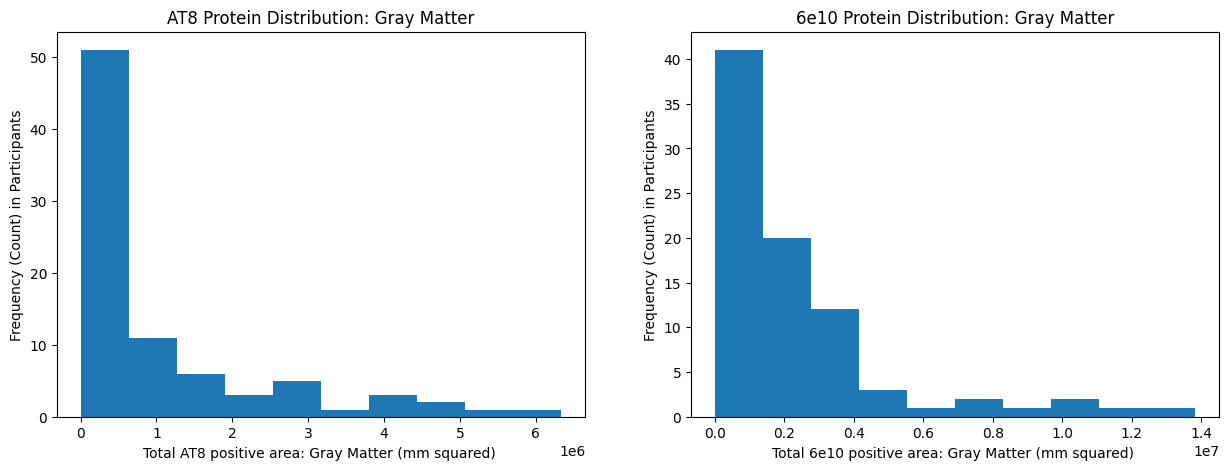

In [9]:
#visualizing AT8 and 6e10 (part 2a, visualizing dependent variables)
fig, ax = plt.subplots(1,2,figsize=(15,5))

#visualizing AT8 via histogram
ax[0].hist(AT8_graymatter)
#labeling axes
ax[0].set_xlabel('Total AT8 positive area: Gray Matter (mm squared) ')
ax[0].set_ylabel('Frequency (Count) in Participants')
#setting title
ax[0].set_title("AT8 Protein Distribution: Gray Matter")

#visualizing 6e10 via histogram
ax[1].hist(Sixe10_graymatter)
#labeling axes
ax[1].set_xlabel('Total 6e10 positive area: Gray Matter (mm squared) ')
ax[1].set_ylabel('Frequency (Count) in Participants')
#setting title
ax[1].set_title("6e10 Protein Dist

In [10]:
#skewness test for AT8 (part 3a: skewness test)
skew_test_AT8 = stats.skewtest(AT8_graymatter)
#printing skew test AT8
print("skew_test_AT8:", skew_test_AT8)
#yes is skewed, p<0.05

#skewness test for 6e10
skew_test_6e10 = stats.skewtest(Sixe10_graymatter)

#printing skew test
print("skew_test_6e10:", skew_test_6e10)
#yes is skewed, p<0.05


skew_test_AT8: SkewtestResult(statistic=np.float64(5.244794913302965), pvalue=np.float64(1.5645626146891252e-07))
skew_test_6e10: SkewtestResult(statistic=np.float64(5.818686919501585), pvalue=np.float64(5.931170822750895e-09))


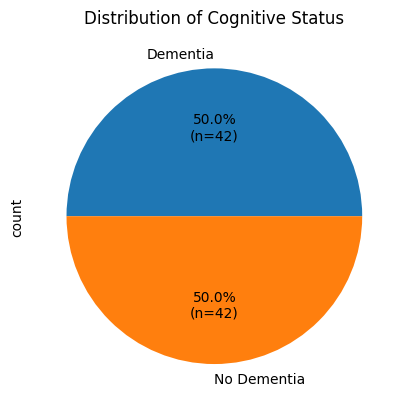

In [11]:
#visualizing distribution of each grouping variable (part 2b)
#making pie chart of alz data
#labeling slices with % and n participants
Alz_data['Cognitive Status'].value_counts().plot(kind='pie', labels=["Dementia", "No Dementia"], autopct=lambda p: f'{p:.1f}%\n(n={int(p * len(Alz_data)/100)})')
#giving pie chart a title
plt.title('Distribution of Cognitive Status')
#showing pie chart
plt.show()



Text(0.5, 1.0, 'Correlation between AT8 and 6e10 Protein in Gray Matter')

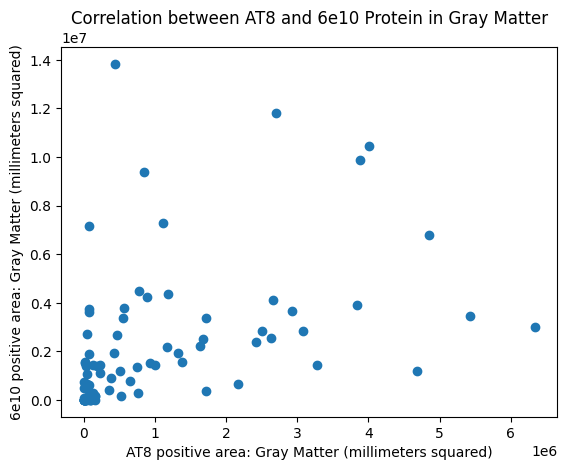

In [15]:
#scatterplot comparing proteins (part 2c)
plt.scatter(AT8_graymatter, Sixe10_graymatter)
#labeling axes
plt.xlabel("AT8 positive area: Gray Matter (millimeters squared)")
plt.ylabel("6e10 positive area: Gray Matter (millimeters squared)")
#adding title
plt.title('Correlation between AT8 and 6e10 Protein in Gray Matter')

Text(0.5, 1.0, '6e10 Positive Area: Gray Matter By Cognitive Status')

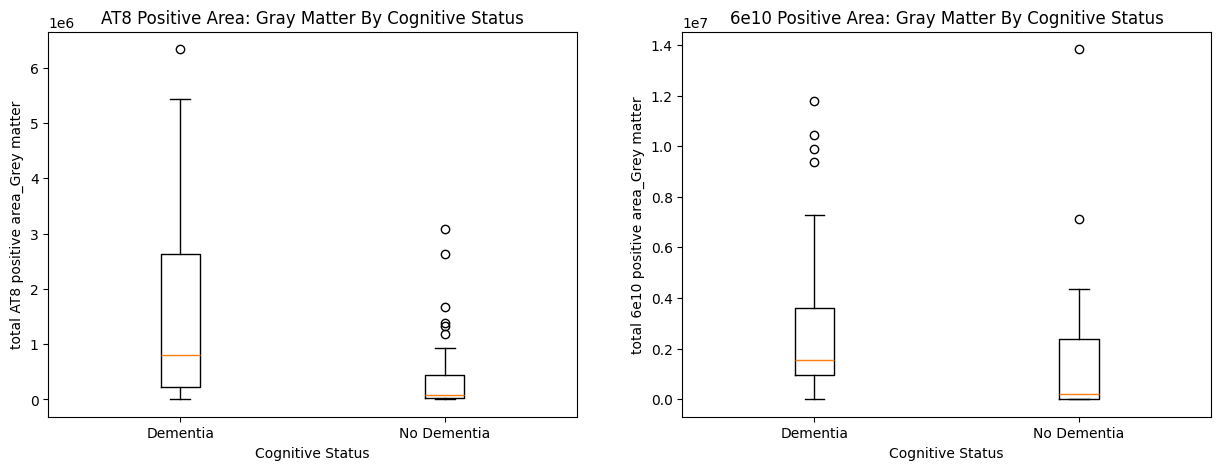

In [18]:
#boxplots comparing dementia vs. no dementia on each protein (part 2d)
#creating yes dementia and no dementia variables
yes_dementia = Alz_data[Alz_data['Cognitive Status'] == 'Dementia']
no_dementia = Alz_data[Alz_data['Cognitive Status'] == 'No dementia']

#creating 2 subplots
fig, ax = plt.subplots(1,2,figsize=(15,5))

#boxplots comparing dementia vs. no dementia on AT8
#creating specific dementia and no variables for AT8
dementia_at8 = yes_dementia['total AT8 positive area_Grey matter']
no_dementia_at8 = no_dementia['total AT8 positive area_Grey matter']

#creating boxplot data
dementia_box_data = [dementia_at8, no_dementia_at8]

#creating boxplot
ax[0].boxplot(dementia_box_data, tick_labels=['Dementia', 'No Dementia'])
#labeling axes
ax[0].set_ylabel('total AT8 positive area_Grey matter')
ax[0].set_xlabel('Cognitive Status')
#setting title
ax[0].set_title('AT8 Positive Area: Gray Matter By Cognitive Status')

#boxplots comparing dementia vs. no dementia on 6e10
#creating specific dementia and no variables for 6e10
dementia_6e10 = yes_dementia['total 6e10 positive area_Grey matter']
no_dementia_6e10 = no_dementia['total 6e10 positive area_Grey matter']

#creating boxplot data
dementia_box_data_6e10 = [dementia_6e10, no_dementia_6e10]

#creating box plot
ax[1].boxplot(dementia_box_data_6e10, tick_labels=['Dementia', 'No Dementia'])
#labeling axes
ax[1].set_ylabel('total 6e10 positive area_Grey matter')
ax[1].set_xlabel('Cognitive Status')
#setting title
ax[1].set_title('6e10 Positive Area: Gray Matter By Cognitive Status')



In [20]:
#ranked sum tests for AT8 and 6e10(part 3d)
#Can see above that distribution is skewed with skewness test
#doing ranked sum test for AT8
print(stats.mannwhitneyu(dementia_at8,no_dementia_at8))
#yes significant difference, p>0.05

#doing ranked sum test for 6e10
print(stats.mannwhitneyu(dementia_6e10,no_dementia_6e10))
#yes significant difference, p>0.05


MannwhitneyuResult(statistic=np.float64(1335.0), pvalue=np.float64(5.163668769570943e-05))
MannwhitneyuResult(statistic=np.float64(1256.0), pvalue=np.float64(0.0008337088211267097))


#TBI Data Analysis

In [22]:
#importing TBI data
TBI_id = pd.read_csv('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/tbi_dementia_ids_final_project.csv')
TBI_pathology = pd.read_csv('https://raw.githubusercontent.com/sashamontgomery/Neur-265/refs/heads/main/tbi_dementia_pathology_final_project.csv')

#merging data sets into one tbi variable
TBI_data = pd.merge(TBI_id,TBI_pathology, on = 'donor_id', how = 'inner')


In [23]:
#looking at tbi variable
TBI_data["ever_tbi_w_loc"]

#creating tau protein and amyloid beta protein variables
tau_protein = TBI_data['ihc_tau2_ffpe']
abeta_protein = TBI_data['ihc_a_beta_ffpe']


Text(0.5, 1.0, '% Amyloid Beta Positive Area Distribution')

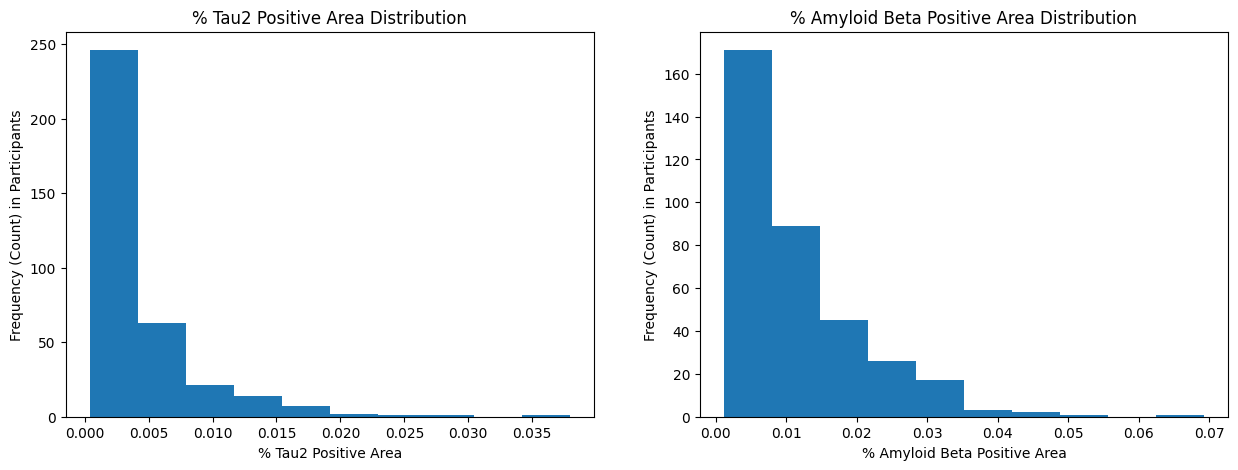

In [24]:
#visualizing Tau2 and Abeta via histograms (part 2a, visualizing dependent variables)

#creating 2 subplots
fig, ax = plt.subplots(1,2,figsize=(15,5))

#making Tau2 histogram
ax[0].hist(tau_protein)
#labeling axes
ax[0].set_xlabel('% Tau2 Positive Area')
ax[0].set_ylabel('Frequency (Count) in Participants')
#setting title
ax[0].set_title("% Tau2 Positive Area Distribution")

#making amyloid beta histogram
ax[1].hist(abeta_protein)
#labeling axes
ax[1].set_xlabel('% Amyloid Beta Positive Area')
ax[1].set_ylabel('Frequency (Count) in Participants')
#setting title
ax[1].set_title("% Amyloid Beta Positive Area Distribution")


In [25]:
#part 3a: skewness test
#skewness test Tau2
skew_test_Tau = stats.skewtest(tau_protein, nan_policy='omit')
#nan_policy = 'omit' removes missing values
print("skew_test_Tau:", skew_test_Tau)
#yes is skewed, p<0.05

#skewness test amyloid beta
skew_test_abeta = stats.skewtest(abeta_protein, nan_policy='omit')
#nan_policy = 'omit' removes missing values

print("skew_test_abeta:", skew_test_abeta)
#yes is skewed, p<0.05


skew_test_Tau: SkewtestResult(statistic=np.float64(13.351176409655334), pvalue=np.float64(1.165929607064861e-40))
skew_test_abeta: SkewtestResult(statistic=np.float64(9.98814278983711), pvalue=np.float64(1.7176975329183922e-23))


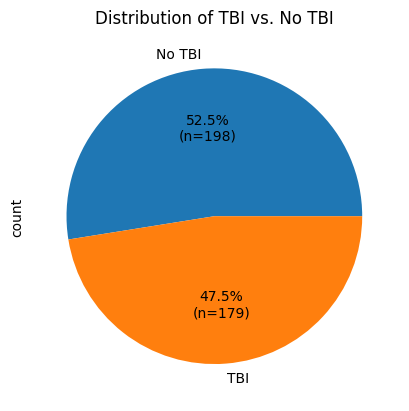

In [27]:
#visualizing distribution of each grouping variable (part 2b)
#making pie chart of TBI data
#labeling slices with % and n participants
TBI_data['ever_tbi_w_loc'].value_counts().plot(kind='pie', labels=["No TBI", "TBI"], autopct=lambda p: f'{p:.1f}%\n(n={int(p * len(TBI_data)/100)})')
#setting a title
plt.title('Distribution of TBI vs. No TBI')
#showing pie chart
plt.show()


Text(0.5, 1.0, 'Correlation between % Positive Area Covered by Tau2 protein and Amyloid beta Protein')

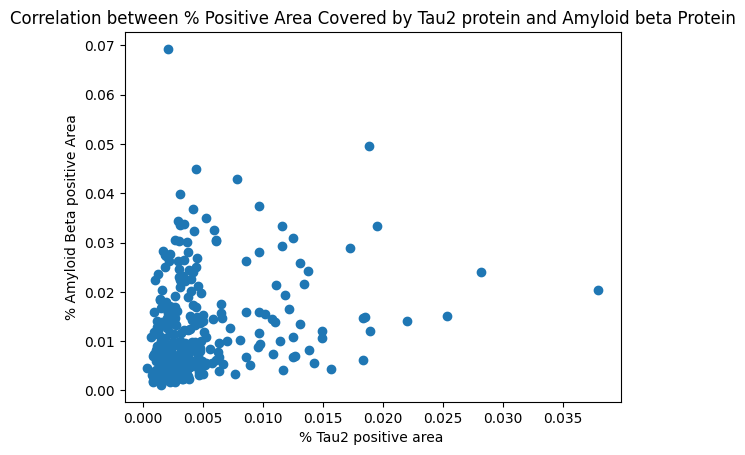

In [26]:
#scatterplot comparing proteins (part 2c)
#creating scatterplot
plt.scatter(tau_protein, abeta_protein)
#labeling axes
plt.xlabel("% Tau2 positive area ")
plt.ylabel("% Amyloid Beta positive Area")
#setting title
plt.title('Correlation between % Positive Area Covered by Tau2 protein and Amyloid beta Protein')

Text(0.5, 1.0, '% Amyloid Beta Positive Area By TBI')

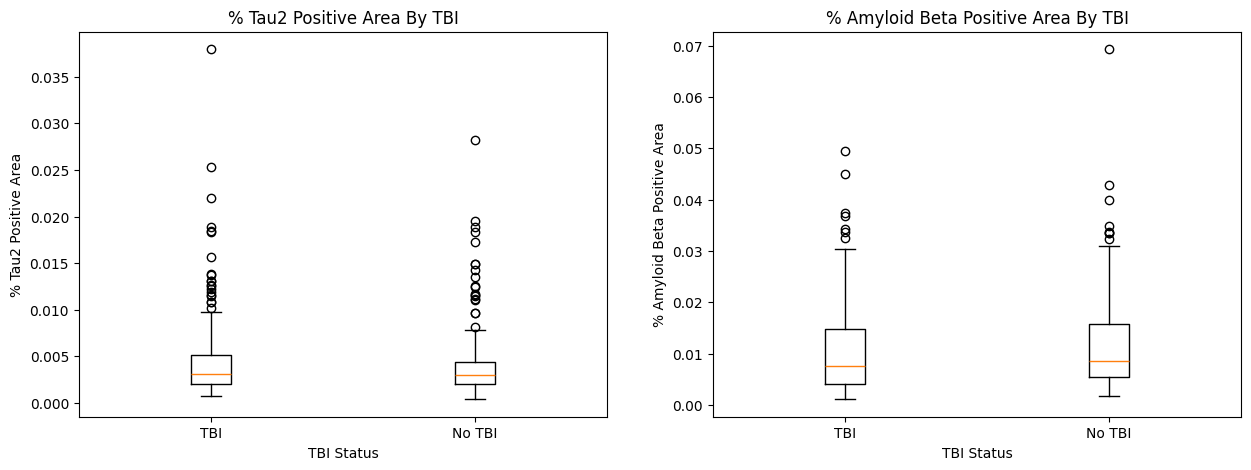

In [28]:
#boxplots comparing TBI vs. no TBI on each protein (part 2d)
#creating 2 subplots
fig, ax = plt.subplots(1,2,figsize=(15,5))

#creating yes tbi and no tbi variables
yes_tbi = TBI_data[TBI_data["ever_tbi_w_loc"] == "Y"]
no_tbi = TBI_data[TBI_data['ever_tbi_w_loc'] == 'N']

#boxplots comparing TBI vs. no TBI on Tau2
#creating tbi and no tbi variables for tau2 specifically
tbi_tau2 = yes_tbi['ihc_tau2_ffpe']
no_tbi_tau2 = no_tbi['ihc_tau2_ffpe']

#creating boxplot data variable
tbi_tau_box_data = [tbi_tau2.dropna(), no_tbi_tau2.dropna()]
#drop.na drops n/a slash missing variables


#creating boxplot with labels
ax[0].boxplot(tbi_tau_box_data, tick_labels=['TBI', 'No TBI'])
#labeling axes
ax[0].set_ylabel('% Tau2 Positive Area')
ax[0].set_xlabel('TBI Status')
#setting title
ax[0].set_title('% Tau2 Positive Area By TBI')

#boxplots comparing tbi vs. no tbi on abeta
#creating tbi and no tbi variables for abeta specifically
tbi_abeta = yes_tbi['ihc_a_beta_ffpe']
no_tbi_abeta = no_tbi['ihc_a_beta_ffpe']

#creating boxplot data variable
tbi_abeta_box_data = [tbi_abeta.dropna(), no_tbi_abeta.dropna()]
#drop.na drops n/a slash missing variables

#creating box plot with labels
ax[1].boxplot(tbi_abeta_box_data, tick_labels=['TBI', 'No TBI'])
#labeling axes
ax[1].set_ylabel('% Amyloid Beta Positive Area')
ax[1].set_xlabel('TBI Status')
#setting title
ax[1].set_title('% Amyloid Beta Positive Area By TBI')


In [29]:
#ranked sum tests for Tau2 and Abeta(part 3d)
#Can see above that distribution is skewed with skewness test
#doing ranked sum test for Tau2 and printing
print(stats.mannwhitneyu(tbi_tau2,no_tbi_tau2, nan_policy='omit'))
#nan_policy = 'omit' removes missing values
#no significant difference


#doing ranked sum test for Abeta and printing
print(stats.mannwhitneyu(tbi_abeta,no_tbi_abeta, nan_policy='omit'))
#nan_policy = 'omit' removes missing values
#no significant difference


MannwhitneyuResult(statistic=np.float64(16908.0), pvalue=np.float64(0.26414925522035826))
MannwhitneyuResult(statistic=np.float64(14515.0), pvalue=np.float64(0.20798317168751268))
